In [1]:
import pandas as pd

df = pd.read_csv("IMDB Dataset.csv.zip")

df.head()

,review,sentiment
0,One of the other reviewers has mentioned that ...,positive
1,A wonderful little production. <br /><br />The...,positive
2,I thought this was a wonderful way to spend ti...,positive
3,Basically there's a family where a little boy ...,negative
4,"Petter Mattei's ""Love in the Time of Money"" is...",positive


In [2]:
df.shape

(50000, 2)

In [3]:
df.columns

Index(['review', 'sentiment'], dtype='object')

Checking Class Distribution

In [4]:
df['sentiment'].value_counts()

,count
sentiment,
positive,25000
negative,25000


Importing Libraries and Loading Stopwords

In [5]:
import re
import nltk

nltk.download('stopwords')

from nltk.corpus import stopwords

[nltk_data] Downloading package stopwords to /root/nltk_data...
[nltk_data]   Unzipping corpora/stopwords.zip.


Text Cleaning

In [6]:
stop_words = set(stopwords.words('english'))

def clean_text(text):
    text = text.lower()
    text = re.sub('[^a-zA-Z]', ' ', text)

    words = text.split()

    words = [word for word in words if word not in stop_words]

    return " ".join(words)

df['clean_review'] = df['review'].apply(clean_text)

Checking Cleaned Text

In [7]:
df[['review','clean_review']].head()

,review,clean_review
0,One of the other reviewers has mentioned that ...,one reviewers mentioned watching oz episode ho...
1,A wonderful little production. <br /><br />The...,wonderful little production br br filming tech...
2,I thought this was a wonderful way to spend ti...,thought wonderful way spend time hot summer we...
3,Basically there's a family where a little boy ...,basically family little boy jake thinks zombie...
4,"Petter Mattei's ""Love in the Time of Money"" is...",petter mattei love time money visually stunnin...


Splitting Data into Training and Testing Sets

In [8]:
from sklearn.model_selection import train_test_split

X = df['clean_review']
y = df['sentiment']

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

Converting Text into Numerical Features using TF-IDF

In [9]:
from sklearn.feature_extraction.text import TfidfVectorizer

vectorizer = TfidfVectorizer(max_features=5000)

X_train = vectorizer.fit_transform(X_train)

X_test = vectorizer.transform(X_test)

Training Logistic Regression Model

In [10]:
from sklearn.linear_model import LogisticRegression

model = LogisticRegression()

model.fit(
    X_train,
    y_train
)

LogisticRegression()

Making Predictions on Test Data

In [11]:
y_pred = model.predict(X_test)

Model Evaluation (Accuracy & Classification Report)

In [12]:
from sklearn.metrics import accuracy_score, classification_report

print("Accuracy:", accuracy_score(y_test,y_pred))

print(classification_report(y_test,y_pred))

Accuracy: 0.8915
              precision    recall  f1-score   support

    negative       0.90      0.88      0.89      4961
    positive       0.88      0.90      0.89      5039

    accuracy                           0.89     10000
   macro avg       0.89      0.89      0.89     10000
weighted avg       0.89      0.89      0.89     10000



Importing Libraries for AUC Calculation

In [13]:
from sklearn.metrics import roc_auc_score
from sklearn.preprocessing import LabelEncoder

Encoding Target Labels

In [14]:
le = LabelEncoder()

y_test_encoded = le.fit_transform(y_test)

 Prediction Probabilities for ROC-AUC

In [15]:
y_prob = model.predict_proba(X_test)[:,1]

Calculating ROC-AUC Score

In [16]:
auc_score = roc_auc_score(
    y_test_encoded,
    y_prob
)

print("ROC-AUC Score:", auc_score)

ROC-AUC Score: 0.9586062016013054


Training and Evaluating SVM Model

In [17]:
from sklearn.svm import LinearSVC
from sklearn.metrics import accuracy_score, classification_report

svm_model = LinearSVC()

svm_model.fit(X_train, y_train)

svm_pred = svm_model.predict(X_test)

print("SVM Accuracy:", accuracy_score(y_test, svm_pred))

print(classification_report(y_test, svm_pred))

SVM Accuracy: 0.8823
              precision    recall  f1-score   support

    negative       0.89      0.87      0.88      4961
    positive       0.88      0.89      0.88      5039

    accuracy                           0.88     10000
   macro avg       0.88      0.88      0.88     10000
weighted avg       0.88      0.88      0.88     10000



Calculating ROC-AUC Score for SVM Model

In [18]:
from sklearn.metrics import roc_auc_score

svm_score = svm_model.decision_function(X_test)

print("SVM AUC:", roc_auc_score(y_test, svm_score))

SVM AUC: 0.953426286455268


Training and Evaluating Naive Bayes Model

In [19]:
from sklearn.naive_bayes import MultinomialNB
from sklearn.metrics import accuracy_score, classification_report, roc_auc_score

nb_model = MultinomialNB()

nb_model.fit(X_train, y_train)

nb_pred = nb_model.predict(X_test)


nb_prob = nb_model.predict_proba(X_test)[:,1]

print("Naive Bayes Accuracy:", accuracy_score(y_test, nb_pred))

print(classification_report(y_test, nb_pred))

print("Naive Bayes AUC:", roc_auc_score(y_test, nb_prob))

Naive Bayes Accuracy: 0.8551
              precision    recall  f1-score   support

    negative       0.86      0.85      0.85      4961
    positive       0.85      0.86      0.86      5039

    accuracy                           0.86     10000
   macro avg       0.86      0.86      0.86     10000
weighted avg       0.86      0.86      0.86     10000

Naive Bayes AUC: 0.9311502511812819


Calculating ROC-AUC Score for Naive Bayes Model

In [20]:
from sklearn.metrics import roc_auc_score

nb_prob = nb_model.predict_proba(X_test)[:,1]

nb_auc = roc_auc_score(y_test, nb_prob)

print("Naive Bayes ROC-AUC Score:", nb_auc)

Naive Bayes ROC-AUC Score: 0.9311502511812819


Confusion Matrix (Logistic Regression Model Evaluation)

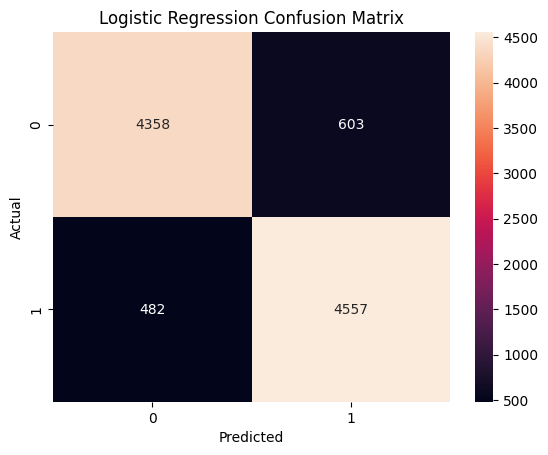

In [21]:
from sklearn.metrics import confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt

cm_lr = confusion_matrix(y_test, y_pred)

sns.heatmap(cm_lr, annot=True, fmt='d')

plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Logistic Regression Confusion Matrix")

plt.show()

Confusion Matrix for SVM Model Evaluation

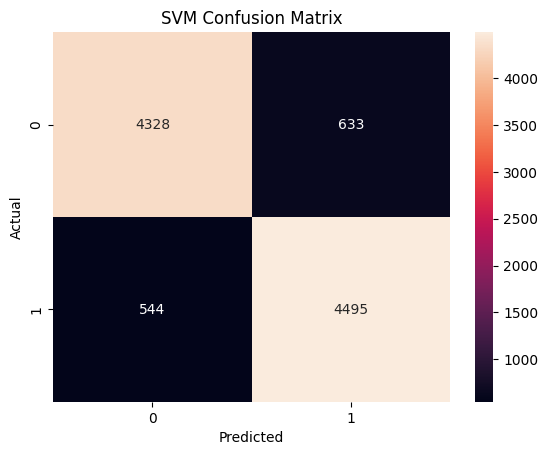

In [22]:
cm_svm = confusion_matrix(y_test, svm_pred)

sns.heatmap(cm_svm, annot=True, fmt='d')
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("SVM Confusion Matrix")
plt.show()

Confusion Matrix for Naive Bayes Model Evaluation

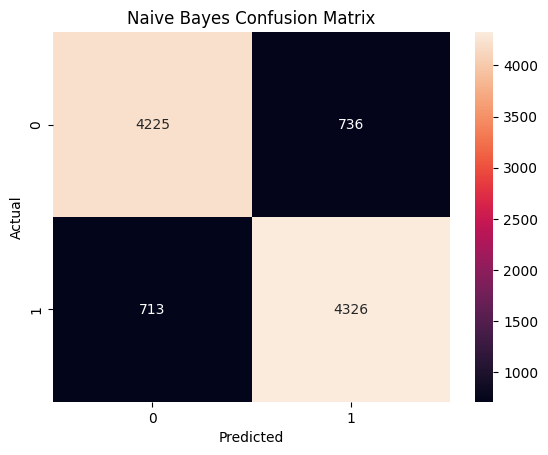

In [23]:
cm_nb = confusion_matrix(y_test, nb_pred)

sns.heatmap(cm_nb, annot=True, fmt='d')
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Naive Bayes Confusion Matrix")
plt.show()

Conclusion:

Logistic Regression → AUC 0.9586
SVM → AUC 0.9534
Naive Bayes → AUC 0.9311

"After comparing all the models and checking their Evaluation metrics and Confusion Matrix, I found that Logistic Regression gave the best performance. It achieved the highest ROC-AUC score of 0.9586 and was able to classify positive and negative reviews effectively. So, I selected Logistic Regression as my final model for this sentiment analysis task."

Saving Trained Model and TF-IDF Vectorizer

In [24]:
import joblib

# Save Logistic Regression model
joblib.dump(model, "sentiment_logistic_model.pkl")

# Save TF-IDF vectorizer
joblib.dump(vectorizer, "tfidf_vectorizer.pkl")

print("Model and Vectorizer saved successfully")

Model and Vectorizer saved successfully


In [25]:
import os
print(os.listdir())

['.config', 'tfidf_vectorizer.pkl', 'IMDB Dataset.csv.zip', 'sentiment_logistic_model.pkl', 'sample_data']


Model checking for both Positive and Negative

In [26]:
import joblib

loaded_model = joblib.load("sentiment_logistic_model.pkl")
loaded_vectorizer = joblib.load("tfidf_vectorizer.pkl")

In [27]:
review = ["This movie is excellent, I loved it and it was a great experience"]

review_vector = loaded_vectorizer.transform(review)

prediction = loaded_model.predict(review_vector)

print(prediction)

['positive']


In [28]:
review = ["This movie was terrible, boring and I hated it"]

review_vector = loaded_vectorizer.transform(review)

prediction = loaded_model.predict(review_vector)

print(prediction)

['negative']
